---
title: Hyperparameter Sensitivity Testing
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

The spatiotemporal DBSCAN procedure we use to create our AR catalog involves several hyperparameters. The final choices of these hyperparameters were largely motivated by our physical understanding of ARs in Antarctica (background domain knowledge), and verified 'by-eye' by tracking down known ARs from numerous case studies in the Antarctic AR literature and checking that their landfalling time, duration, etc. matches what we found in our catalog. However, there are several perturbations to these parameters that we could have made, and this notebook documents the sensitivity of various AR metrics to these perturbations, conveying the overall importance of getting certain hyperparameters "right."

## Hyperparameters Overview

In the clustering algorithm, there are several hyperparameters:
+ `epsilon_space`: spatial neighborhood, given in fractions of synoptic scale (1000 km)
+ `epsilon_time`: time neighborhood, given in hours
+ `minpts`: the minimum number of neighboring points to be considered a core point
+ `n_rep_pts`: the number of representative points to sample from each cluster at each time step

In the below sections, we explore the sensitivity of the clustering results to each of these hyperparameters. In our explorations and ground-truthing exercises, we found that an ideal set of hyperparameters are `epsilon_space: 0.5`, `epsilon_time: 12`, `minpts: 5`, and `n_rep_pts: 10`. We will perturb these hyperparameters individually and explore how they affect clustering results relative to this base setting.

In [7]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
sys.path.append(str((Path(os.getcwd()).parents[3]/'packages')))
from display_utils import *
import seaborn as sns


path = Path('/scratch/users/butlerj/extreme_antarctic_ars/catalog_runs/')

In [13]:
# small helper function to grab storms from dictionaries of dataframes
def process_cts(dictionary):

    res_dict = {}
    total_cts = []
    landfall_cts = []
    for param, df in dictionary.items():
        landfalling = df[df.is_landfalling]
        total_cts.append(df.shape[0])
        landfall_cts.append(landfalling.shape[0])

    res_dict = {'total': total_cts, 'landfalling': landfall_cts}
    res_df = pd.DataFrame(res_dict, index=list(dictionary.keys()))

    return res_df
    

In [14]:
baseline_df = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')

## `epsilon_space` perturbations

In [72]:
# constructing dictionaries to organize results
space_dict = {}
space_dict['0.5'] = baseline_df
space_dict['0.25'] = pd.read_hdf(path/'epsspace0.25_epstime12_minpts5_nreppts10_seed12345.h5')
space_dict['0.75'] = pd.read_hdf(path/'epsspace0.75_epstime12_minpts5_nreppts10_seed12345.h5')
space_dict['1.0'] = pd.read_hdf(path/'epsspace1.0_epstime12_minpts5_nreppts10_seed12345.h5')

In [73]:
res_df = process_cts(space_dict)
res_df

,total,landfalling
0.5,8714,3179
0.25,11660,3630
0.75,8121,3082
1.0,7710,3031


In [113]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
space_percents = (res_df - res_df.loc['0.5'])/res_df.loc['0.5']
space_percents

,total,landfalling
0.5,0.000000,0.000000
0.25,0.338077,0.141869
0.75,-0.068051,-0.030513
1.0,-0.115217,-0.046556


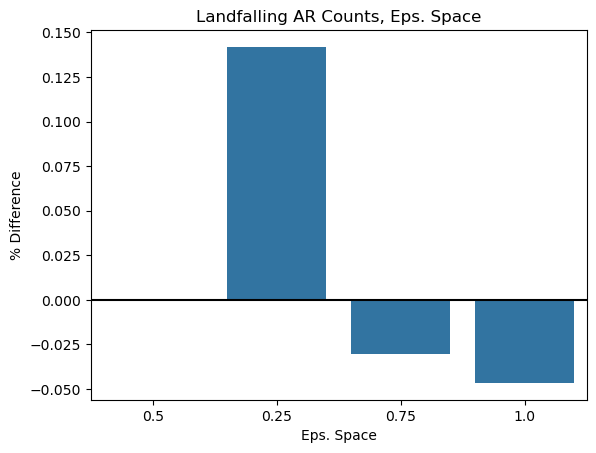

In [77]:
sns.barplot(data=space_percents, x=space_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Eps. Space')
plt.xlabel('Eps. Space')
plt.ylabel('% Difference');

**Takeaway:** Higher spatial epsilons lead to less ARs, which makes sense as ARs that are close to one another in the same time step are more likely to be grouped together. However, once you are at half a synoptic scale (`0.5`), the percent difference in the number of landfalling ARs is relatively small. It also appears that the total number of ARs is more sensitive to these perturbations. `0.25` has substantially more landfalling ARs, but this is much too small as groups of AR points within this small distance (250 km) are likely part of the same system.

## `epsilon_time` perturbations

In [115]:
# constructing dictionaries to organize results
time_dict = {}
time_dict['9'] = pd.read_hdf(path/'epsspace0.5_epstime9.0_minpts5_nreppts10_seed12345.h5')
time_dict['12'] = baseline_df
time_dict['15'] = pd.read_hdf(path/'epsspace0.5_epstime15.0_minpts5_nreppts10_seed12345.h5')
time_dict['18'] = pd.read_hdf(path/'epsspace0.5_epstime18.0_minpts5_nreppts10_seed12345.h5')
time_dict['21'] = pd.read_hdf(path/'epsspace0.5_epstime21.0_minpts5_nreppts10_seed12345.h5')
time_dict['24'] = pd.read_hdf(path/'epsspace0.5_epstime24.0_minpts5_nreppts10_seed12345.h5')

In [116]:
res_df = process_cts(time_dict)
res_df

,total,landfalling
9,9263,3307
12,8714,3179
15,8356,3077
18,8063,2997
21,7820,2919
24,7610,2865


In [117]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
time_percents = (res_df - res_df.loc['12'])/res_df.loc['12']
time_percents

,total,landfalling
9,0.063002,0.040264
12,0.000000,0.000000
15,-0.041083,-0.032086
18,-0.074707,-0.057251
21,-0.102594,-0.081787
24,-0.126693,-0.098773


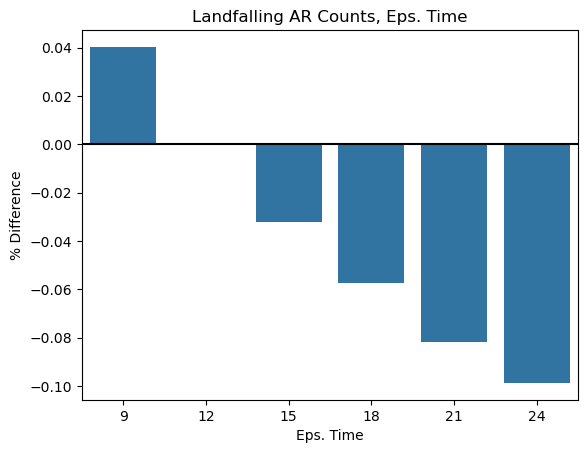

In [118]:
sns.barplot(data=time_percents, x=time_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Eps. Time')
plt.xlabel('Eps. Time')
plt.ylabel('% Difference');

**Takeaway:** This parameter seems to be consistently impacting the number of landfalling and total numbers of ARs. As before, it seems the total number of ARs is more sensitive to these perturbations. When searching for neighboring points, this parameter represents the time window where we can consider other points to potentially be a part of this same cluster. Anything higher than 18 hours seems too long, since if an AR disappears for 18 hours, it is likely another system.

## `minpts` perturbations

In [119]:
minpts_dict = {}
minpts_dict['3'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts3_nreppts10_seed12345.h5')
minpts_dict['5'] = baseline_df
minpts_dict['8'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts8_nreppts10_seed12345.h5')
minpts_dict['10'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts10_nreppts10_seed12345.h5')

In [121]:
res_df = process_cts(minpts_dict)
res_df

,total,landfalling
3,8901,3194
5,8714,3179
8,8182,3023
10,7835,2945


In [122]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
minpts_percents = (res_df - res_df.loc['5'])/res_df.loc['5']
minpts_percents

,total,landfalling
3,0.021460,0.004718
5,0.000000,0.000000
8,-0.061051,-0.049072
10,-0.100872,-0.073608


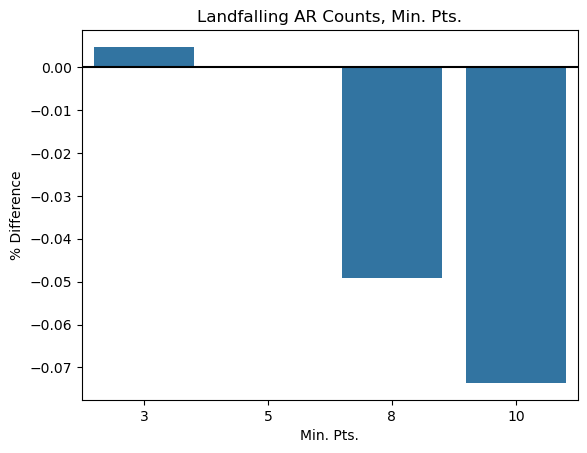

In [123]:
sns.barplot(data=minpts_percents, x=minpts_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Min. Pts.')
plt.xlabel('Min. Pts.')
plt.ylabel('% Difference');

**Takeaway:** It's unsurprising that the higher the `min_pts` parameter, the less storms you get since you require more points witihn a neighborhood of each other to instantiate a cluster. The differences don't seem that substantial, but 5 intuitively makes sense given the spatiotemporal clustering step works by stitching groups of 10 points from each cluster across time.

## `n_rep_pts` perturbations

In [124]:
reppts_dict = {}
reppts_dict['5'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts5_seed12345.h5')
reppts_dict['10'] = baseline_df
reppts_dict['15'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts15_seed12345.h5')

In [125]:
res_df = process_cts(reppts_dict)
res_df

,total,landfalling
5,8664,3105
10,8714,3179
15,8608,3159


In [126]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
rep_pts_percents = (res_df - res_df.loc['10'])/res_df.loc['10']
rep_pts_percents

,total,landfalling
5,-0.005738,-0.023278
10,0.000000,0.000000
15,-0.012164,-0.006291


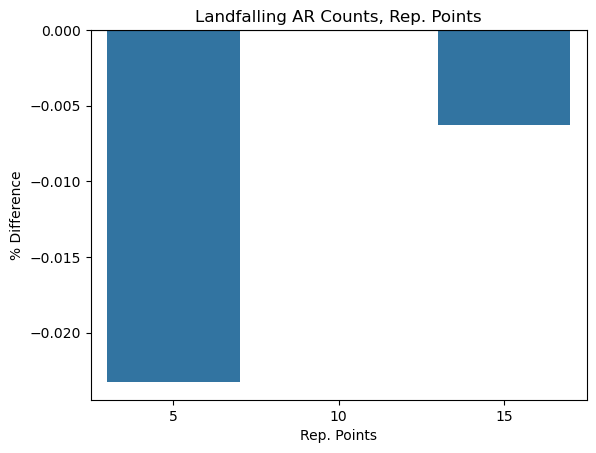

In [127]:
sns.barplot(data=rep_pts_percents, x=rep_pts_percents.index, y='landfalling', errorbar=None)
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Rep. Points')
plt.xlabel('Rep. Points')
plt.ylabel('% Difference');

**Takeaway:** results seem fairly stable to perturbations of this parameter.

## seed perturbations

We also have a random component to this clustering algorithm. What if we switch up our random seed, how sensitive are the results?

In [128]:
seed_dict = {}
seed_dict['1111'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed1111.h5')
seed_dict['12345'] = baseline_df
seed_dict['2222'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed2222.h5')
seed_dict['3333'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed3333.h5')
seed_dict['4444'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed4444.h5')
seed_dict['5555'] = pd.read_hdf(path/'epsspace0.5_epstime12_minpts5_nreppts10_seed5555.h5')

In [129]:
res_df = process_cts(seed_dict)
res_df

,total,landfalling
1111,8753,3168
12345,8714,3179
2222,8749,3172
3333,8773,3165
4444,8740,3167
5555,8741,3168


In [130]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
seed_percents = (res_df - res_df.loc['12345'])/res_df.loc['12345']
seed_percents

,total,landfalling
1111,0.004476,-0.003460
12345,0.000000,0.000000
2222,0.004017,-0.002202
3333,0.006771,-0.004404
4444,0.002984,-0.003775
5555,0.003098,-0.003460


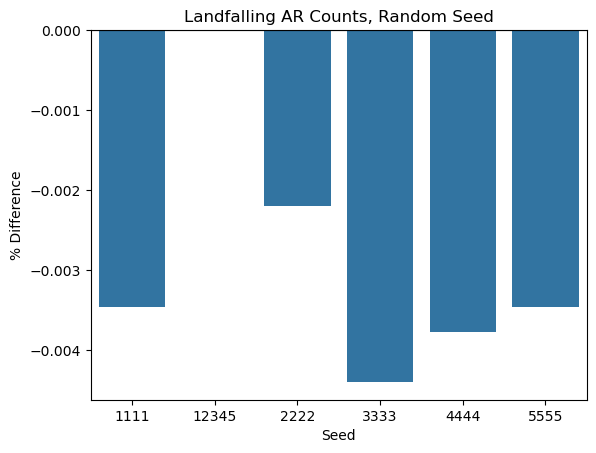

In [131]:
sns.barplot(data=seed_percents, x=seed_percents.index, y='landfalling', errorbar=None)
plt.title('Landfalling AR Counts, Random Seed')
plt.axhline(y=0, linestyle='-', color='black')
plt.xlabel('Seed')
plt.ylabel('% Difference');

**Takeaway:** Results seem very stable to perturbations of the random seed, indicating that the randomness is not introducing too much variability into the numbers of ARs created.

## Perturbations Together

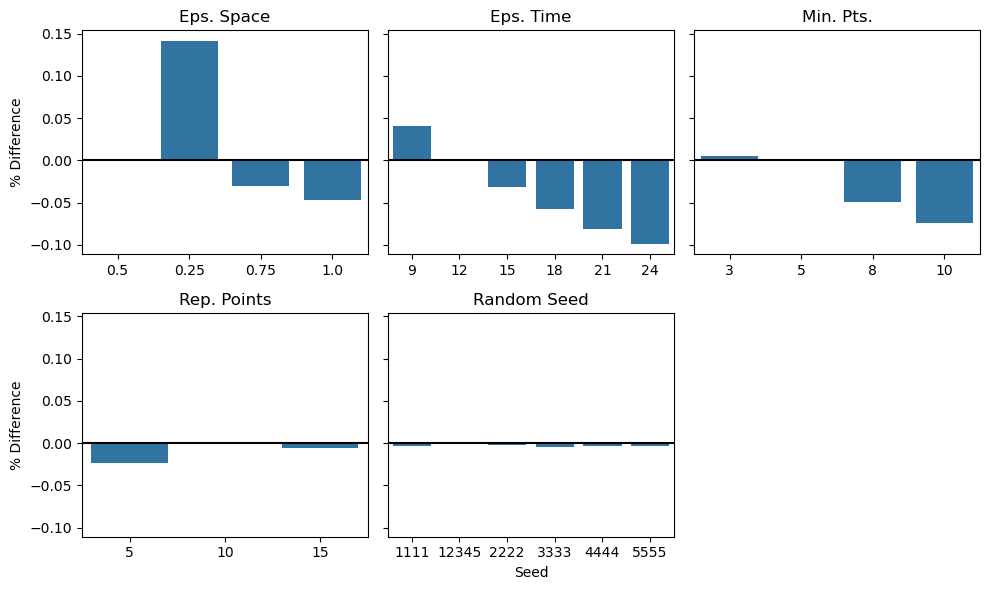

In [132]:
fig, axs = plt.subplots(2, 3, sharey=True)

sns.barplot(data=space_percents, x=space_percents.index, y='landfalling', errorbar=None, ax=axs[0,0])
axs[0,0].axhline(y=0, linestyle='-', color='black')
axs[0,0].set_title('Eps. Space')
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('% Difference');

sns.barplot(data=time_percents, x=time_percents.index, y='landfalling', errorbar=None, ax=axs[0,1])
axs[0,1].axhline(y=0, linestyle='-', color='black')
axs[0,1].set_title('Eps. Time')
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('');

sns.barplot(data=minpts_percents, x=minpts_percents.index, y='landfalling', errorbar=None, ax=axs[0,2])
axs[0,2].axhline(y=0, linestyle='-', color='black')
axs[0,2].set_title('Min. Pts.')
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('');

sns.barplot(data=rep_pts_percents, x=rep_pts_percents.index, y='landfalling', errorbar=None, ax=axs[1,0])
axs[1,0].axhline(y=0, linestyle='-', color='black')
axs[1,0].set_title('Rep. Points')
axs[1,0].set_xlabel('')
axs[1,0].set_ylabel('% Difference');

sns.barplot(data=seed_percents, x=seed_percents.index, y='landfalling', errorbar=None, ax=axs[1,1])
axs[1,1].set_title('Random Seed')
axs[1,1].axhline(y=0, linestyle='-', color='black')
axs[1,1].set_xlabel('Seed')
axs[1,1].set_ylabel('');

axs[1,2].set_axis_off()


fig.set_size_inches((10,6))
plt.tight_layout()